In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 리눅스 나눔 폰트 직접 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False



# tensorflow import mnist

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

I0000 00:00:1774831597.535354    2691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774831597.869791    2691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774831602.284177    2691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


((60000, 28, 28), (10000, 28, 28))

In [3]:
type(X_train)

numpy.ndarray

In [4]:
#픽셀값 정규화
X_train = X_train.reshape(-1, 28, 28, 1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0
X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

# 합성곱 신경망의 구조  

In [5]:
from tensorflow.keras import Sequential, layers
model = Sequential(
  [
    layers.Input(shape=(28,28,1)), #3차원 이미지 1장의 입력
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.1),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), #분류 계층
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
  ])
model.summary()

I0000 00:00:1774831609.202367    2691 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# 모델

In [6]:
model.layers[0].get_weights() #초기값 (랜덤)

[array([[[[-3.29687893e-02,  1.06537372e-01, -7.24673048e-02,
           -3.54418159e-03, -4.12141904e-02,  1.10176846e-01,
           -5.37925661e-02,  9.40162987e-02, -3.76319289e-02,
            4.93228883e-02,  1.11826405e-01,  6.67850077e-02,
           -2.87296921e-02, -4.81419191e-02, -2.86393464e-02,
            7.18610287e-02,  2.88050473e-02, -7.98636898e-02,
           -6.44567087e-02, -6.60303012e-02,  3.12701166e-02,
           -1.10690325e-01,  1.23344675e-01, -8.57775733e-02,
            1.76617801e-02,  4.28992361e-02,  8.07178617e-02,
            1.24180153e-01,  4.36124355e-02,  7.08867013e-02,
            1.50393397e-02, -1.00870594e-01]],
 
         [[-9.90162045e-02, -5.07407710e-02, -2.73676515e-02,
            3.66732925e-02,  7.39077479e-02,  8.79840404e-02,
           -6.72188327e-02, -1.05534606e-01, -1.10134408e-01,
           -6.22012317e-02, -1.06966823e-01, -9.72296670e-02,
           -7.07259327e-02,  8.36335272e-02,  1.31571129e-01,
            1.1548571

# 컴파일

In [7]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, batch_size=128, epochs=10,
                        validation_split=0.2, #추가 
                      verbose=1)

Epoch 1/10


I0000 00:00:1774831610.956505    3250 service.cc:153] XLA service 0x74ff180331f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774831610.956531    3250 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774831610.981750    3250 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774831611.111680    3250 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774831611.164130    3250 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1791__.33


 61/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4396 - loss: 1.6575

I0000 00:00:1774831615.391226    3250 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8755 - loss: 0.3951 - val_accuracy: 0.9748 - val_loss: 0.0883
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9592 - loss: 0.1362 - val_accuracy: 0.9830 - val_loss: 0.0597
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9698 - loss: 0.1008 - val_accuracy: 0.9838 - val_loss: 0.0553
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0830 - val_accuracy: 0.9857 - val_loss: 0.0476
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9786 - loss: 0.0713 - val_accuracy: 0.9874 - val_loss: 0.0420
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9811 - loss: 0.0627 - val_accuracy: 0.9882 - val_loss: 0.0431
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0565 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9834 - loss: 0.0529 - val_accuracy: 0.9900 - val

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9915 - loss: 0.0238


# 시각화

In [10]:
import matplotlib.pyplot as plt
import numpy as np


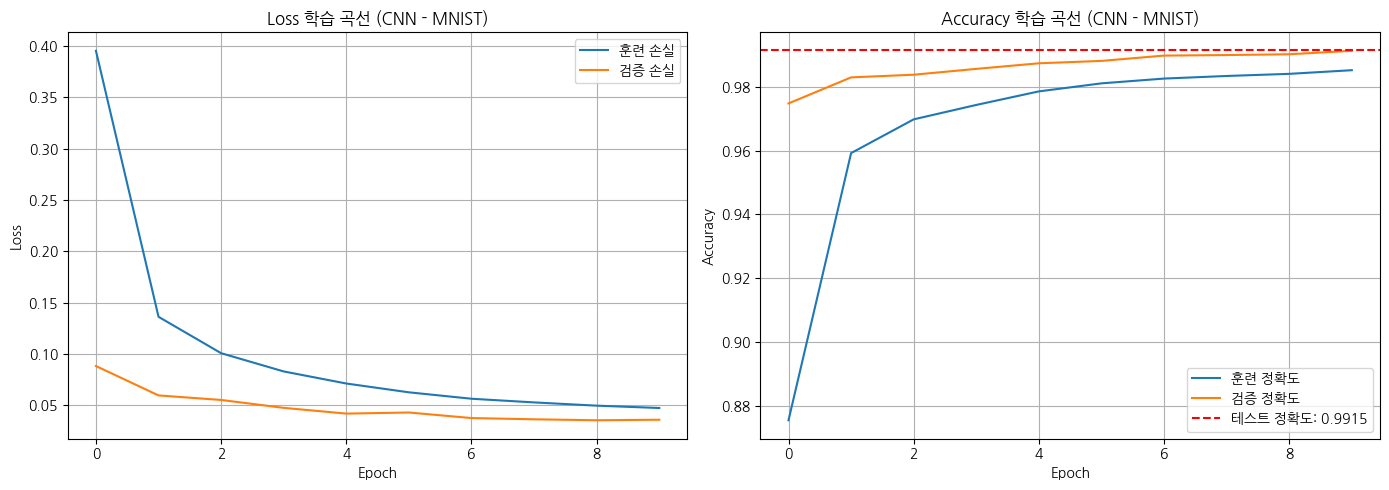

테스트 Loss    : 0.0238
테스트 Accuracy: 99.15%


In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선 (CNN - MNIST)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선 (CNN - MNIST)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# 테스트 정확도 기준선 추가
axes[1].axhline(y=acc, color='red', linestyle='--',
                label=f'테스트 정확도: {acc:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc*100:.2f}%")

# END

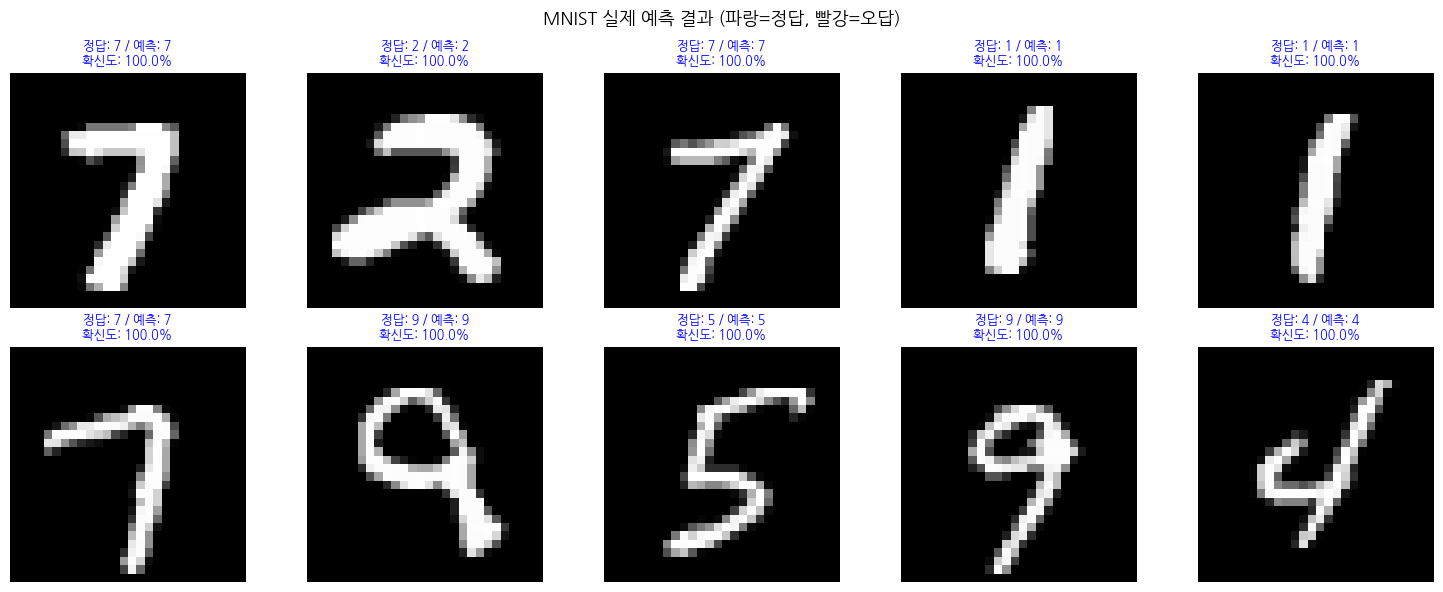

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 테스트 이미지 10개 랜덤 선택
indices = np.random.randint(0, len(X_test), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]

    # 예측
    pred_prob  = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    pred_label = np.argmax(pred_prob)
    confidence = pred_prob[0][pred_label] * 100

    # 시각화
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].set_title(
        f'정답: {true_label} / 예측: {pred_label}\n확신도: {confidence:.1f}%',
        color='blue' if true_label == pred_label else 'red',
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('MNIST 실제 예측 결과 (파랑=정답, 빨강=오답)', fontsize=13)
plt.tight_layout()
plt.show()